# MGT 209 Exercise — MBA Program Cluster Analysis

**Course:** MGT 209: Marketing Management  
**Session:** Data-based Segmentation and Targeting  
**Exercise:** Segmenting MBA programs  
**Dataset:** `cluster_MBA.csv`

## Exercise Background

The course excercise describe an MBA program director who wants to understand the segment of the MBA market in which her program belongs. The dataset contains **54 top MBA programs** and five program characteristics:

- average undergraduate GPA
- average GMAT score
- acceptance rate (%)
- average starting salary and bonus
- out-of-state tuition and fees

The purpose is to **perform a cluster analysis with five anchors**. The course also introduces **K-means clustering** and **Euclidean distance**.

### Analytical objective

Group the 54 MBA programs into five clusters based on the five course-specified program characteristics, profile the resulting clusters, and inspect which programs have similar market characteristics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

DATA_PATH = "/mnt/data/cluster_MBA.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head(10))


Shape: (54, 7)
Columns: ['Rank', 'School', 'GPA', 'GMAT', 'Acceptance', 'Salary', 'Tuition']


,Rank,School,GPA,GMAT,Acceptance,Salary,Tuition
0,1,Harvard University,3.660,724,11.100,139735,60610
1,2,Standford University,3.700,730,7.000,140972,55200
2,3,University of Pennsylvania,3.560,718,18.800,137311,58244
3,4,Massachusetts Institute of Technology,3.510,710,13.300,132618,52900
4,5,Northwestern University,3.540,712,21.100,130092,54225
5,6,University of Chicago,3.520,719,21.900,133424,54252
6,7,University of California-Berkeley,3.640,715,12.200,129776,53396
7,8,Columbia University,3.500,716,15.900,134233,58350
8,9,Dartmouth College,3.520,718,17.900,138220,56555
9,10,Yale University,3.520,719,19.100,125735,53900


## 1. Data Inspection

`Rank` and `School` identify/descriptively label programs. They are **not** used in the distance calculation.

The five clustering variables are exactly the program characteristics named in the course slide: `GPA`, `GMAT`, `Acceptance`, `Salary`, and `Tuition`.


In [2]:
cluster_vars = ["GPA", "GMAT", "Acceptance", "Salary", "Tuition"]

print("Missing values:")
display(df[cluster_vars].isna().sum().to_frame("Missing"))

print("\nDescriptive statistics:")
display(df[cluster_vars].describe().T)


Missing values:


,Missing
GPA,0
GMAT,0
Acceptance,0
Salary,0
Tuition,0



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
GPA,54.000,3.409,0.110,3.200,3.320,3.400,3.500,3.700
GMAT,54.000,681.444,26.048,631.000,663.750,682.500,699.750,730.000
Acceptance,54.000,30.383,11.579,7.000,24.450,28.800,36.650,69.700
Salary,54.000,"106,342.241","19,699.733","62,745.000","93,367.750","103,031.500","124,883.500","140,972.000"
Tuition,54.000,"44,833.722","9,801.787","10,600.000","39,298.000","46,684.500","52,473.000","60,610.000"


## 2. Why Scale the Variables?

K-means uses Euclidean distance. In the raw data, GPA is around 3–4, GMAT is in the hundreds, acceptance is a percentage, and salary/tuition are in tens of thousands of dollars.

If raw values were used directly, variables with large numerical units could dominate the Euclidean distance. For this reproduction, each clustering variable is therefore converted to a **z-score**:


z_ij = (x_ij -x_bar_j) / s_j


This gives the five variables comparable numerical scales while preserving relative differences among programs.


In [3]:
X = df[cluster_vars].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(X_scaled, columns=cluster_vars)
display(scaled_df.describe().T[["mean", "std", "min", "max"]])


,mean,std,min,max
GPA,-0.000,1.009,-1.918,2.681
GMAT,-0.000,1.009,-1.955,1.882
Acceptance,0.000,1.009,-2.038,3.427
Salary,-0.000,1.009,-2.234,1.774
Tuition,0.000,1.009,-3.525,1.625


## 3. Five-Cluster K-means Solution

The course slide asks for **five anchors**, so this reproduction sets **K = 5**.

K-means follows the course logic:

1. initialize five centroids;
2. assign each program to its nearest centroid using Euclidean distance;
3. recompute centroids;
4. repeat until assignments stabilize.

A fixed random state and multiple initializations are used so the Python result is reproducible.


In [4]:
kmeans = KMeans(n_clusters=5, random_state=209, n_init=50)
raw_cluster = kmeans.fit_predict(X_scaled)

df_result = df.copy()
df_result["Cluster"] = raw_cluster + 1

print("Iterations to convergence:", kmeans.n_iter_)
print("Within-cluster sum of squares (inertia):", round(kmeans.inertia_, 3))
display(df_result[["Rank", "School"] + cluster_vars + ["Cluster"]].head(15))


Iterations to convergence: 9
Within-cluster sum of squares (inertia): 68.419


,Rank,School,GPA,GMAT,Acceptance,Salary,Tuition,Cluster
0,1,Harvard University,3.660,724,11.100,139735,60610,2
1,2,Standford University,3.700,730,7.000,140972,55200,2
2,3,University of Pennsylvania,3.560,718,18.800,137311,58244,2
3,4,Massachusetts Institute of Technology,3.510,710,13.300,132618,52900,2
4,5,Northwestern University,3.540,712,21.100,130092,54225,2
5,6,University of Chicago,3.520,719,21.900,133424,54252,2
6,7,University of California-Berkeley,3.640,715,12.200,129776,53396,2
7,8,Columbia University,3.500,716,15.900,134233,58350,2
8,9,Dartmouth College,3.520,718,17.900,138220,56555,2
9,10,Yale University,3.520,719,19.100,125735,53900,2


## 4. Cluster Sizes and Centroids

The most useful interpretation is in the **original units**, so the standardized centroids are transformed back to GPA, GMAT, acceptance rate, salary, and tuition.

Cluster numbers are algorithmic labels only; they do not imply an ordinal ranking.


In [5]:
cluster_sizes = df_result["Cluster"].value_counts().sort_index().rename("Programs")

centroids_original = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=cluster_vars,
    index=[f"Cluster {i}" for i in range(1, 6)]
)

centroids_z = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=cluster_vars,
    index=[f"Cluster {i}" for i in range(1, 6)]
)

print("Cluster sizes:")
display(cluster_sizes.to_frame())

print("\nCentroids in original units:")
display(centroids_original)

print("\nStandardized centroid profiles (z-scores):")
display(centroids_z)


Cluster sizes:


,Programs
Cluster,
1,6
2,12
3,16
4,2
5,18



Centroids in original units:


,GPA,GMAT,Acceptance,Salary,Tuition
Cluster 1,3.510,656.167,34.533,"83,607.333","27,007.667"
Cluster 2,3.549,717.000,16.708,"132,509.417","55,066.167"
Cluster 3,3.353,689.812,30.806,"113,053.375","49,066.312"
Cluster 4,3.350,651.500,63.200,"78,775.000","46,878.000"
Cluster 5,3.337,662.056,34.094,"93,573.333","39,964.667"



Standardized centroid profiles (z-scores):


,GPA,GMAT,Acceptance,Salary,Tuition
Cluster 1,0.933,-0.980,0.362,-1.165,-1.836
Cluster 2,1.293,1.378,-1.192,1.341,1.054
Cluster 3,-0.509,0.324,0.037,0.344,0.436
Cluster 4,-0.538,-1.160,2.861,-1.413,0.211
Cluster 5,-0.661,-0.751,0.324,-0.654,-0.501


## 5. Programs in Each Cluster

This table makes the segmentation concrete by showing which MBA programs are grouped together. The original course question is about locating programs within the broader MBA market, so program membership is central to interpretation.


In [6]:
for cluster in sorted(df_result["Cluster"].unique()):
    members = (
        df_result.loc[df_result["Cluster"] == cluster,
                      ["Rank", "School", "GPA", "GMAT", "Acceptance", "Salary", "Tuition"]]
        .sort_values("Rank")
    )
    print(f"\nCLUSTER {cluster} — {len(members)} programs")
    display(members)



CLUSTER 1 — 6 programs


,Rank,School,GPA,GMAT,Acceptance,Salary,Tuition
32,33,Texas A&M University-College Station,3.500,647,27.400,97279,32927
33,34,Brigham Young University,3.550,670,52.400,103369,10600
40,41,University of Texas-Dallas,3.540,662,25.800,76272,25447
45,46,University of Florida,3.510,678,24.000,78522,30347
50,51,University of Arkansas-Fayetteville,3.500,649,45.000,62745,27011
52,53,Temple University,3.460,631,32.600,83457,35714



CLUSTER 2 — 12 programs


,Rank,School,GPA,GMAT,Acceptance,Salary,Tuition
0,1,Harvard University,3.660,724,11.100,139735,60610
1,2,Standford University,3.700,730,7.000,140972,55200
2,3,University of Pennsylvania,3.560,718,18.800,137311,58244
3,4,Massachusetts Institute of Technology,3.510,710,13.300,132618,52900
4,5,Northwestern University,3.540,712,21.100,130092,54225
5,6,University of Chicago,3.520,719,21.900,133424,54252
6,7,University of California-Berkeley,3.640,715,12.200,129776,53396
7,8,Columbia University,3.500,716,15.900,134233,58350
8,9,Dartmouth College,3.520,718,17.900,138220,56555
9,10,Yale University,3.520,719,19.100,125735,53900



CLUSTER 3 — 16 programs


,Rank,School,GPA,GMAT,Acceptance,Salary,Tuition
11,12,Duke University,3.440,689,26.500,128666,52152
12,13,University of Michigan-Ann Arbor,3.400,703,32.200,127817,52944
13,14,University of Virginia,3.400,701,24.600,127595,52000
15,16,Cornell University,3.290,691,27.100,122329,53200
16,17,University of Texas-Austin,3.430,692,25.300,118410,47836
17,18,Carnegie Mellon University,3.350,686,23.900,117650,54800
18,19,Emory University,3.300,681,35.100,121050,44098
19,20,U. of North Carolina-Chapel Hill,3.310,689,37.700,101904,50613
20,21,University of Southern California,3.300,687,27.000,109619,51784
21,22,Washington University in St. Louis,3.320,696,28.100,99354,46975



CLUSTER 4 — 2 programs


,Rank,School,GPA,GMAT,Acceptance,Salary,Tuition
42,43,Tulane University,3.300,670,56.700,76398,49936
51,52,Case Western Reserve Univ.,3.400,633,69.700,81152,43820



CLUSTER 5 — 18 programs


,Rank,School,GPA,GMAT,Acceptance,Salary,Tuition
22,23,Indiana University-Bloomington,3.320,670,38.000,106195,45351
24,25,Ohio State University,3.400,674,26.700,91696,43800
27,28,University of Wisconsin-Madison,3.330,680,30.300,105333,26757
29,30,Arizona State University,3.360,674,32.200,95255,37345
31,32,Georgia Institute of Technology,3.310,674,26.000,97376,38616
34,35,University of Washington,3.400,675,43.500,97970,39219
36,37,Boston College,3.390,656,30.700,98283,37110
37,38,Boston University,3.320,684,30.400,94434,41366
38,39,University of Illinois-Urbana-Champaign,3.400,650,28.100,85916,33457
39,40,University of Rochester,3.460,675,36.100,81117,46887


## 6. Visualize Cluster Profiles

The standardized centroid chart shows how each cluster differs from the overall dataset. Values above zero indicate that a cluster is above the sample mean on that characteristic; values below zero indicate that it is below the sample mean.


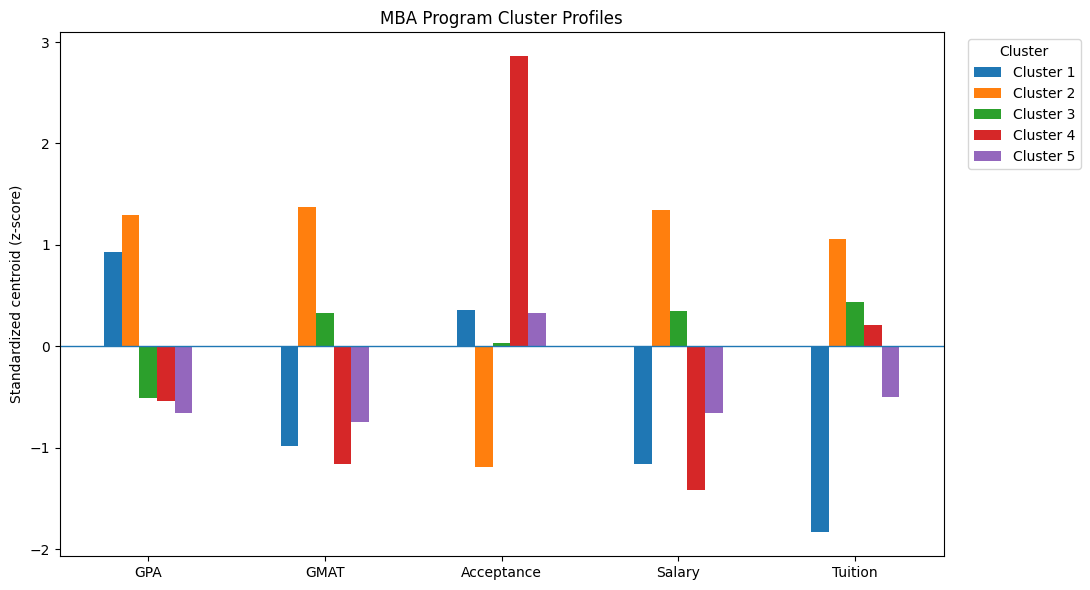

In [7]:
ax = centroids_z.T.plot(kind="bar", figsize=(11, 6))
ax.axhline(0, linewidth=1)
ax.set_ylabel("Standardized centroid (z-score)")
ax.set_title("MBA Program Cluster Profiles")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. Two-Dimensional Visualization with PCA

The clustering itself uses **all five standardized variables**. PCA is used only to create a two-dimensional visualization of the multivariate cluster solution; it is not used to generate the clusters.


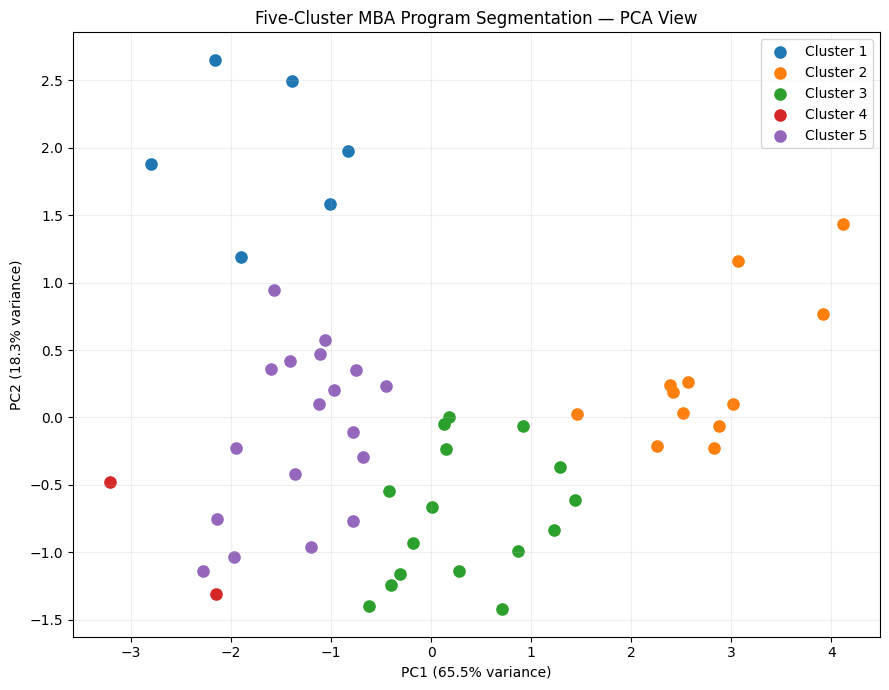

Variance represented by the two plotted components: 83.8%


In [8]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "Cluster": df_result["Cluster"],
    "School": df_result["School"]
})

plt.figure(figsize=(9, 7))
for cluster, group in plot_df.groupby("Cluster"):
    plt.scatter(group["PC1"], group["PC2"], s=65, label=f"Cluster {cluster}")

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("Five-Cluster MBA Program Segmentation — PCA View")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

print("Variance represented by the two plotted components:",
      f"{pca.explained_variance_ratio_.sum():.1%}")


## 8. Euclidean-Distance Verification

The course describes assigning each observation to the closest centroid. The calculation below verifies that each MBA program is assigned to the nearest of the five final centroids in standardized five-dimensional space.


In [9]:
centers = kmeans.cluster_centers_
distances = np.sqrt(((X_scaled[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2))

distance_df = pd.DataFrame(
    distances,
    columns=[f"Distance to Cluster {i}" for i in range(1, 6)]
)

verification = pd.concat(
    [df_result[["School", "Cluster"]].reset_index(drop=True), distance_df],
    axis=1
)
verification["Nearest Cluster"] = distances.argmin(axis=1) + 1
verification["Assignment Verified"] = verification["Cluster"] == verification["Nearest Cluster"]

display(verification.head(15))
print("All programs assigned to their nearest final centroid:",
      verification["Assignment Verified"].all())


,School,Cluster,Distance to Cluster 1,Distance to Cluster 2,Distance to Cluster 3,Distance to Cluster 4,Distance to Cluster 5,Nearest Cluster,Assignment Verified
0,Harvard University,2,5.765,1.347,3.994,6.957,5.361,2,True
1,Standford University,2,5.837,1.756,4.399,7.383,5.660,2,True
2,University of Pennsylvania,2,5.075,0.461,2.889,5.976,4.389,2,True
3,Massachusetts Institute of Technology,2,4.604,0.584,2.487,5.850,3.880,2,True
4,Northwestern University,2,4.434,0.463,2.335,5.432,3.766,2,True
5,University of Chicago,2,4.641,0.540,2.369,5.538,3.896,2,True
6,University of California-Berkeley,2,4.837,0.953,3.388,6.341,4.581,2,True
7,Columbia University,2,5.017,0.577,2.576,5.884,4.131,2,True
8,Dartmouth College,2,4.994,0.440,2.659,5.912,4.206,2,True
9,Yale University,2,4.481,0.506,2.312,5.512,3.768,2,True


All programs assigned to their nearest final centroid: True


## 9. Interpreting the Segments

Rather than treating cluster numbers as rankings, the table below identifies each cluster's **relative profile**. Interpretation should be based on the combination of characteristics, not on one variable alone.


In [10]:
profile_words = {}
for idx, row in centroids_z.iterrows():
    high = row.sort_values(ascending=False).head(2).index.tolist()
    low = row.sort_values().head(2).index.tolist()
    profile_words[idx] = {
        "Most above sample mean": ", ".join(high),
        "Most below sample mean": ", ".join(low)
    }

profile_summary = pd.DataFrame(profile_words).T
profile_summary.insert(0, "Programs", cluster_sizes.values)
display(profile_summary)


,Programs,Most above sample mean,Most below sample mean
Cluster 1,6,"GPA, Acceptance","Tuition, Salary"
Cluster 2,12,"GMAT, Salary","Acceptance, Tuition"
Cluster 3,16,"Tuition, Salary","GPA, Acceptance"
Cluster 4,2,"Acceptance, Tuition","Salary, GMAT"
Cluster 5,18,"Acceptance, Tuition","GMAT, GPA"


### Marketing interpretation

This exercise treats MBA programs as objects in a market and segments them according to observable program characteristics. Programs within a cluster have more similar profiles across GPA, GMAT, acceptance rate, starting salary, and tuition than programs assigned to different clusters.

The segmentation can help an MBA program director understand the program's **competitive neighborhood**: which schools have broadly similar admissions, outcomes, and price characteristics. That is consistent with the Session 4 emphasis on using data-based segmentation to identify distinct groups before making targeting or positioning decisions.

The cluster solution itself does **not** determine which segment is most attractive. Targeting requires considering factors such as segment size/growth, attractiveness, and the firm's objectives and resources.


## 10. Exercise Takeaways

1. Clustering **54 MBA programs using five program characteristics and five anchors**.
2. K-means assigns observations to the nearest centroid using **Euclidean distance**.
3. Because the variables have very different units, this excercise standardizes the five clustering variables before fitting K-means.
4. `Rank` and `School` are not used to create the clusters; they are used to identify and describe the resulting groups.
5. Cluster labels are arbitrary and should not be interpreted as rankings.
6. The substantive value comes from profiling each cluster and identifying programs with similar market characteristics.

### Source / Provenance

Course-provided instructional dataset `cluster_MBA.csv`, used in **MGT 209: Marketing Management**, Session 005 — **Data-based Segmentation and Targeting**, UC Riverside, Winter 2023. 